
# 🚀 Day 13 (Level 2): Gradient Descent Variants – Industry Grade

## 🎯 Objective
This notebook goes beyond basics and focuses on:

- Deep theory + intuition
- Impact of batch size & learning rate
- Convergence behavior analysis
- Real-world simulation (Fraud detection style data)
- Visualization-driven understanding

---



# 🧠 Deep Theory

## Gradient Descent Recap

We aim to minimize loss:

L = (1/N) Σ (y_pred - y_true)^2

Update rule:

θ = θ - η * ∇L

Where:
- θ = parameters
- η = learning rate
- ∇L = gradient

---

## Why Variants Matter in Industry

| Problem | Solution |
|--------|---------|
| Huge dataset | SGD / Mini-batch |
| Slow convergence | Mini-batch |
| Noisy gradients | Batch |
| GPU usage | Mini-batch |

---


In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)



# 🏦 Real-World Simulation: Fraud Detection Dataset

We simulate:
- Transaction amount
- Fraud score (linear + noise)

Goal:
- Learn relationship using GD variants


In [3]:

X = np.random.rand(1000) * 100  # transaction amount
noise = np.random.normal(0, 10, 1000)

y = 0.5 * X + 20 + noise  # fraud risk score


In [5]:

def compute_loss(y_pred, y):
    return np.mean((y_pred - y)**2)


# 🟢 Batch Gradient Descent (Experiment)

In [6]:

w, b = 0, 0
lr = 0.0001
losses_batch = []

for i in range(100):
    y_pred = w * X + b
    loss = compute_loss(y_pred, y)
    
    grad_w = np.mean(2 * (y_pred - y) * X)
    grad_b = np.mean(2 * (y_pred - y))
    
    w -= lr * grad_w
    b -= lr * grad_b
    
    losses_batch.append(loss)

print("Batch -> w:", w, "b:", b)


Batch -> w: 0.7994049514771348 b: 0.11526913255244471


# 🟡 SGD (Experiment)

In [11]:

w, b = 0, 0
lr = 0.00001
losses_sgd = []

for epoch in range(5):
    for i in range(len(X)):
        y_pred = w * X[i] + b
        loss = (y_pred - y[i])**2
        
        grad_w = 2 * (y_pred - y[i]) * X[i]
        grad_b = 2 * (y_pred - y[i])
        
        w -= lr * grad_w
        b -= lr * grad_b
        
        losses_sgd.append(loss)

print("SGD -> w:", w, "b:", b)

SGD -> w: 0.7882061731953821 b: 0.5224077868453796


# 🔵 Mini-Batch GD (Experiment)

In [16]:
w, b = 0, 0
lr = 0.0001
batch_size = 32
losses_mb = []

for epoch in range(20):

    # 🔀 Shuffle data at start of each epoch
    indices = np.random.permutation(len(X))
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, len(X), batch_size):
        Xb = X_shuffled[i:i+batch_size]
        yb = y_shuffled[i:i+batch_size]

        y_pred = w * Xb + b

        grad_w = np.mean(2 * (y_pred - yb) * Xb)
        grad_b = np.mean(2 * (y_pred - yb))

        w -= lr * grad_w
        b -= lr * grad_b

    # ✅ Track full dataset loss (better)
    epoch_loss = compute_loss(w * X + b, y)
    losses_mb.append(epoch_loss)

print("Mini-batch -> w:", w, "b:", b)


Mini-batch -> w: 0.778819633499883 b: 0.6650255074995703


# 📊 Convergence Comparison

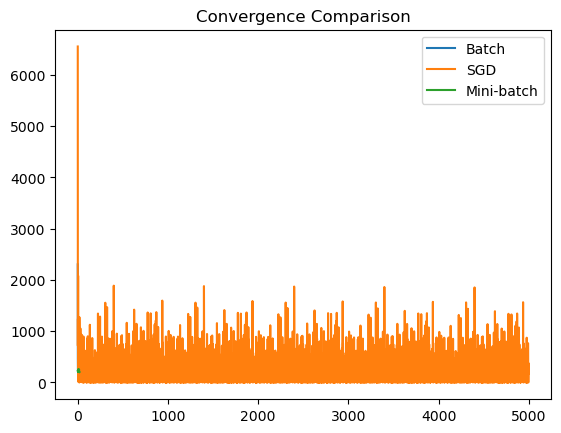

In [17]:

plt.figure()
plt.plot(losses_batch, label="Batch")
plt.plot(losses_sgd, label="SGD")
plt.plot(losses_mb, label="Mini-batch")
plt.legend()
plt.title("Convergence Comparison")
plt.show()


# 🔬 Learning Rate Experiment

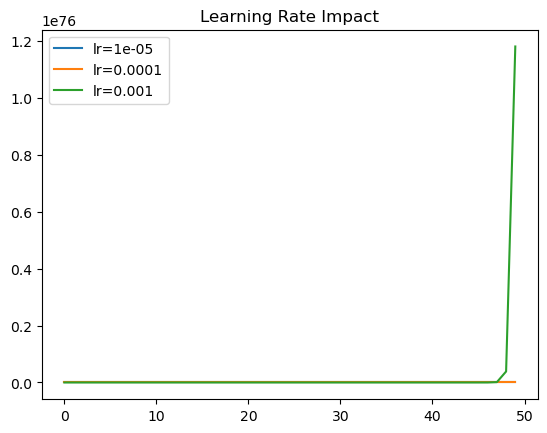

In [18]:

lrs = [0.00001, 0.0001, 0.001]

for lr in lrs:
    w, b = 0, 0
    losses = []
    
    for i in range(50):
        y_pred = w * X + b
        loss = compute_loss(y_pred, y)
        
        grad_w = np.mean(2 * (y_pred - y) * X)
        grad_b = np.mean(2 * (y_pred - y))
        
        w -= lr * grad_w
        b -= lr * grad_b
        
        losses.append(loss)
    
    plt.plot(losses, label=f"lr={lr}")

plt.legend()
plt.title("Learning Rate Impact")
plt.show()


# 🔬 Batch Size Experiment

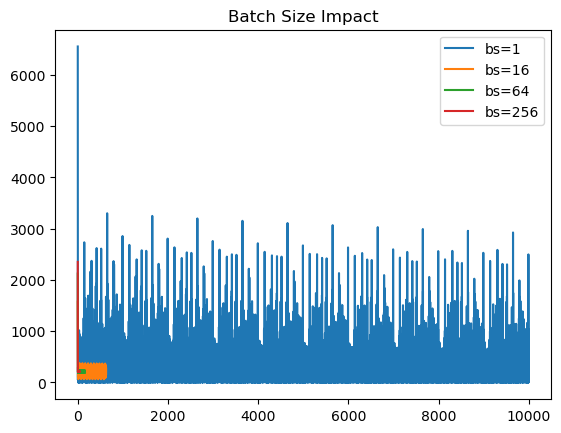

In [19]:

batch_sizes = [1, 16, 64, 256]

for bs in batch_sizes:
    w, b = 0, 0
    losses = []
    
    for epoch in range(10):
        for i in range(0, len(X), bs):
            Xb = X[i:i+bs]
            yb = y[i:i+bs]
            
            y_pred = w * Xb + b
            loss = compute_loss(y_pred, yb)
            
            grad_w = np.mean(2 * (y_pred - yb) * Xb)
            grad_b = np.mean(2 * (y_pred - yb))
            
            w -= 0.0001 * grad_w
            b -= 0.0001 * grad_b
            
            losses.append(loss)
    
    plt.plot(losses, label=f"bs={bs}")

plt.legend()
plt.title("Batch Size Impact")
plt.show()



# 🧠 Final Insights (Industry)

- Mini-batch dominates modern ML
- Batch size impacts:
  - Speed
  - Stability
  - Generalization
- Learning rate is critical

---

## 🚀 Real-World Mapping

| System | GD Type |
|------|--------|
| Fraud detection | Mini-batch |
| Online ads | SGD |
| Small ML model | Batch |

---

## 🎯 Next Step

👉 Optimizers (Adam, Momentum, RMSProp)
